## Importation du dépôt GitHub

Ce notebook dépend de fichiers externes (comme `src/utils.py`) qui font partie d'un dépôt GitHub. Pour que le notebook fonctionne, nous devons cloner le dépôt dans l'environnement Colab.

In [ ]:
import os
import sys
from pathlib import Path
from google.colab import drive

# 1) Monter Google Drive
drive.mount('/content/drive', force_remount=False)

# 2) Détecter automatiquement la racine du repo
candidate_roots = [
    Path('/content/drive/MyDrive/sparkle-movie'),
    Path('/content/drive/MyDrive/sparkle-movie/sparkle-movie'),
    Path('/content/sparkle-movie'),
]

project_path = next(
    (p for p in candidate_roots if (p / 'src').exists() and (p / 'data').exists()),
    None,
)

# 3) Fallback: cloner dans le runtime Colab si aucun repo valide n'est trouvé
if project_path is None:
    project_path = Path('/content/sparkle-movie')
    if not project_path.exists():
        !git clone https://github.com/bruno-coulet/sparkle-movie.git /content/sparkle-movie

# 4) Se placer dans le repo et exposer la racine à utils.py
os.chdir(project_path.as_posix())
if project_path.as_posix() not in sys.path:
    sys.path.insert(0, project_path.as_posix())
os.environ['SPARKLE_MOVIE_ROOT'] = project_path.as_posix()

print(f'Repo actif: {project_path}')
print(f'Dossier courant: {Path.cwd()}')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Vérification de l'environnement actif (pas de re-clone ici)
from pathlib import Path
import os

repo_root = Path(os.environ.get('SPARKLE_MOVIE_ROOT', Path.cwd().as_posix())).resolve()

if not (repo_root / 'src').exists():
    raise RuntimeError(f"Repo invalide: {repo_root}. Le dossier 'src' est introuvable.")

print(f'Racine repo validée: {repo_root}')

fatal: destination path 'sparkle-movie' already exists and is not an empty directory.


Maintenant que le dépôt est cloné et que le répertoire de travail est défini, les importations comme `import src.utils` devraient fonctionner correctement.

## Téléchargement et préparation du dataset `ml-latest`

Nous allons télécharger le dataset `ml-latest` (environ 335 Mo) directement dans l'environnement Colab. Ce dataset sera considéré comme notre source de données "raw_big".

In [3]:
# URL du dataset ml-latest.zip
DATASET_URL = "https://files.grouplens.org/datasets/movielens/ml-latest.zip"
LOCAL_ZIP_FILE = "ml-latest.zip"
EXTRACTED_DIR = "ml-latest"
TARGET_DATA_DIR = "data/raw_big"

import os
import shutil

print(f"Téléchargement de {DATASET_URL}...")
!wget -nc {DATASET_URL} -O {LOCAL_ZIP_FILE}
print("Téléchargement terminé.")

Téléchargement de https://files.grouplens.org/datasets/movielens/ml-latest.zip...
--2026-04-17 17:14:03--  https://files.grouplens.org/datasets/movielens/ml-latest.zip
Resolving files.grouplens.org (files.grouplens.org)... 128.101.96.204
Connecting to files.grouplens.org (files.grouplens.org)|128.101.96.204|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 350896731 (335M) [application/zip]
Saving to: ‘ml-latest.zip’

ml-latest.zip       100%[===================>] 334.64M  19.3MB/s    in 19s     

2026-04-17 17:14:24 (17.4 MB/s) - ‘ml-latest.zip’ saved [350896731/350896731]

Téléchargement terminé.


In [4]:
# Décompression du fichier ZIP
print(f"Décompression de {LOCAL_ZIP_FILE}...")
!unzip -o {LOCAL_ZIP_FILE}
print("Décompression terminée.")

# Vérifier si le répertoire extrait existe
if not os.path.isdir(EXTRACTED_DIR):
    print(f"Erreur: Le répertoire '{EXTRACTED_DIR}' n'a pas été trouvé après la décompression.")
else:
    print(f"Répertoire extrait : {EXTRACTED_DIR}/")

Décompression de ml-latest.zip...
Archive:  ml-latest.zip
   creating: ml-latest/
  inflating: ml-latest/tags.csv      
  inflating: ml-latest/links.csv     
  inflating: ml-latest/README.txt    
  inflating: ml-latest/ratings.csv   
  inflating: ml-latest/genome-tags.csv  
  inflating: ml-latest/genome-scores.csv  
  inflating: ml-latest/movies.csv    
Décompression terminée.
Répertoire extrait : ml-latest/


In [5]:
# Création du répertoire cible si nécessaire et déplacement des fichiers CSV
import os
from pathlib import Path

# Récupérer la racine du projet (qui doit être /content/sparkle-movie/)
project_root = Path(os.getcwd())

target_path = project_root / TARGET_DATA_DIR

# Créer le dossier cible s'il n'existe pas
target_path.mkdir(parents=True, exist_ok=True)

source_dir = project_root / EXTRACTED_DIR

# Fichiers à déplacer
files_to_move = ["movies.csv", "ratings.csv", "links.csv"]

for file_name in files_to_move:
    source_file = source_dir / file_name
    destination_file = target_path / file_name
    if source_file.exists():
        shutil.move(source_file, destination_file)
        print(f"Déplacé {source_file} vers {destination_file}")
    else:
        print(f"Attention: {source_file} n'existe pas.")

print(f"Fichiers déplacés vers {target_path}")

# Supprimer le répertoire extrait et le fichier zip après le déplacement (optionnel)
if source_dir.exists():
    shutil.rmtree(source_dir)
    print(f"Répertoire source '{source_dir}' supprimé.")
if Path(LOCAL_ZIP_FILE).exists():
    Path(LOCAL_ZIP_FILE).unlink()
    print(f"Fichier ZIP '{LOCAL_ZIP_FILE}' supprimé.")

Déplacé /content/sparkle-movie/ml-latest/movies.csv vers /content/sparkle-movie/data/raw_big/movies.csv
Déplacé /content/sparkle-movie/ml-latest/ratings.csv vers /content/sparkle-movie/data/raw_big/ratings.csv
Déplacé /content/sparkle-movie/ml-latest/links.csv vers /content/sparkle-movie/data/raw_big/links.csv
Fichiers déplacés vers /content/sparkle-movie/data/raw_big
Répertoire source '/content/sparkle-movie/ml-latest' supprimé.
Fichier ZIP 'ml-latest.zip' supprimé.


### Mise à jour de `DATA_SOURCE`

Maintenant que les données `ml-latest` sont en place dans `data/raw_big`, nous allons ajuster la variable `DATA_SOURCE` pour utiliser cette source.

In [6]:
import importlib
from pathlib import Path

import matplotlib.pyplot as plt
import src.utils as utils

utils = importlib.reload(utils)

from pyspark.sql import functions as F

<div style="color: #849dc9; background-color: #223f4d; padding: 10px; border-radius: 8px;" >

<h1>Notebook EDA de MovieLens</h1>

<h2>Sélection de la source</h2>

Modifier uniquement la constante `DATA_SOURCE` dans la cellule suivante.

Sources autorisées dans ce notebook :
- `raw_small` -> `data/raw_small` (CSV)
- `raw_big` -> `data/raw_big` (CSV)

Exemple :
- `DATA_SOURCE = "raw_small"`

Note importante :
- Ce notebook EDA lit les donnees brutes (`raw_*`), puis applique le nettoyage en memoire.
- Les analyses (baseline, split, tendances) sont faites sur les donnees nettoyees.
- Les artefacts nettoyes/splittes sont ensuite sauvegardes dans `data/processed/*` pour le notebook de modelisation.
- `links.csv` est charge uniquement pour les sources CSV (`raw_*`).

</div>

In [7]:
DATA_SOURCE = "raw_big"

PROJECT_ROOT = utils.get_project_root()

dataset_format, path_ratings, path_movies = utils.resolve_data_source_paths(
    DATA_SOURCE, project_root=PROJECT_ROOT
)

print(f"Racine projet: {PROJECT_ROOT}")
print(f"Source: {DATA_SOURCE}")
print(f"Format: {dataset_format}")
print(f"ratings: {path_ratings}")
print(f"movies: {path_movies}")

Racine projet: /content/sparkle-movie
Source: raw_big
Format: csv
ratings: /content/sparkle-movie/data/raw_big/ratings.csv
movies: /content/sparkle-movie/data/raw_big/movies.csv


<div style="color: #849dc9; background-color: #223f4d; padding: 10px; border-radius: 8px;" >
Chargement des datasets

In [8]:
# Initialisation de la session Spark avec plus de mémoire pour le pilote
from pyspark.sql import SparkSession

spark = (
    SparkSession.builder.appName("MovieLensEDA")
    .config("spark.driver.memory", "8g") # Augmenter la memoire du driver
    .getOrCreate()
)

# Réduction du niveau de log pour éviter les messages d'avertissement et d'information
# qui peuvent être nombreux lors du chargement et du traitement des données
# Seuls les messages d'erreur seront affichés.
spark.sparkContext.setLogLevel("ERROR")

# Chargement des CSV  Path.as_posix() → convertit un chemin en chaîne de caractères avec des / (format POSIX)
df_ratings = utils.load_ratings_dataframe(spark, path_ratings.as_posix())
df_movies = utils.load_movies_dataframe(spark, path_movies.as_posix())

# La vérification préalable évite des analyses incohérentes si le fichier attendu est absent.
path_links = path_ratings.parent / "links.csv"
if not path_links.exists():
    raise FileNotFoundError(f"Fichier links.csv introuvable: {path_links}")
df_links = utils.load_links_dataframe(spark, path_links.as_posix())

<div style="color: #849dc9; background-color: #223f4d; padding: 10px; border-radius: 8px;" >
Ratings : aperçu de la structure et des 10 premières lignes

In [9]:
print("--- ratings : Schema ---")
df_ratings.printSchema()
print("--- ratings : 10 premières lignes ---")
df_ratings.show(10, truncate=False)


--- ratings : Schema ---
root
 |-- userId: integer (nullable = true)
 |-- movieId: integer (nullable = true)
 |-- rating: float (nullable = true)
 |-- timestamp: long (nullable = true)

--- ratings : 10 premières lignes ---
+------+-------+------+----------+
|userId|movieId|rating|timestamp |
+------+-------+------+----------+
|1     |1      |4.0   |1225734739|
|1     |110    |4.0   |1225865086|
|1     |158    |4.0   |1225733503|
|1     |260    |4.5   |1225735204|
|1     |356    |5.0   |1225735119|
|1     |381    |3.5   |1225734105|
|1     |596    |4.0   |1225733524|
|1     |1036   |5.0   |1225735626|
|1     |1049   |3.0   |1225734079|
|1     |1066   |4.0   |1225736961|
+------+-------+------+----------+
only showing top 10 rows


<div style="color: #849dc9; background-color: #223f4d; padding: 10px; border-radius: 8px;" >
movies : aperçu de la structure et des 10 premières lignes

In [10]:
print("--- movies : Schema ---")
df_movies.printSchema()
print("--- movies : 10 premières lignes ---")
df_movies.show(10, truncate=False)

--- movies : Schema ---
root
 |-- movieId: integer (nullable = true)
 |-- title: string (nullable = true)
 |-- genres: string (nullable = true)

--- movies : 10 premières lignes ---
+-------+----------------------------------+-------------------------------------------+
|movieId|title                             |genres                                     |
+-------+----------------------------------+-------------------------------------------+
|1      |Toy Story (1995)                  |Adventure|Animation|Children|Comedy|Fantasy|
|2      |Jumanji (1995)                    |Adventure|Children|Fantasy                 |
|3      |Grumpier Old Men (1995)           |Comedy|Romance                             |
|4      |Waiting to Exhale (1995)          |Comedy|Drama|Romance                       |
|5      |Father of the Bride Part II (1995)|Comedy                                     |
|6      |Heat (1995)                       |Action|Crime|Thriller                      |
|7      |Sabrina 

<div style="color: #849dc9; background-color: #223f4d; padding: 10px; border-radius: 8px;" >
Links : aperçu de la structure et des 10 premières lignes

In [11]:
if df_links is not None:
    print("--- links : Schema ---")
    df_links.printSchema()
    print("--- links : 10 premières lignes ---")
    df_links.show(10, truncate=False)

--- links : Schema ---
root
 |-- movieId: integer (nullable = true)
 |-- imdbId: integer (nullable = true)
 |-- tmdbId: integer (nullable = true)

--- links : 10 premières lignes ---
+-------+------+------+
|movieId|imdbId|tmdbId|
+-------+------+------+
|1      |114709|862   |
|2      |113497|8844  |
|3      |113228|15602 |
|4      |114885|31357 |
|5      |113041|11862 |
|6      |113277|949   |
|7      |114319|11860 |
|8      |112302|45325 |
|9      |114576|9091  |
|10     |113189|710   |
+-------+------+------+
only showing top 10 rows


<div style="color: #849dc9; background-color: #223f4d; padding: 10px; border-radius: 8px;" >
<h2>Nettoyage des donnees</h2>
On applique `clean_data` pour retirer les valeurs manquantes critiques et les doublons.
</div>

In [ ]:
# Re-initialisation robuste de la session Spark pour le nettoyage
from pyspark.sql import SparkSession

spark = (
    SparkSession.builder.appName("MovieLensEDA")
    .master("local[*]")
    .config("spark.driver.memory", "8g")
    .getOrCreate()
)
spark.sparkContext.setLogLevel("ERROR")

In [19]:
# Nettoyage des DataFrames
df_ratings_clean, df_movies_clean = utils.clean_data(df_ratings, df_movies)

AssertionError: 

In [20]:
print(f"Lignes ratings avant/apres: {df_ratings.count()} / {df_ratings_clean.count()}")
print(f"Lignes movies avant/apres: {df_movies.count()} / {df_movies_clean.count()}")

Py4JJavaError: An error occurred while calling o281.count.
: org.apache.spark.SparkException: [INTERNAL_ERROR] The "count" action failed. You hit a bug in Spark or the Spark plugins you use. Please, report this bug to the corresponding communities or vendors, and provide the full stack trace. SQLSTATE: XX000
	at org.apache.spark.SparkException$.internalError(SparkException.scala:107)
	at org.apache.spark.sql.execution.QueryExecution$.toInternalError(QueryExecution.scala:643)
	at org.apache.spark.sql.execution.QueryExecution$.withInternalError(QueryExecution.scala:656)
	at org.apache.spark.sql.classic.Dataset.$anonfun$withAction$1(Dataset.scala:2232)
	at org.apache.spark.sql.execution.SQLExecution$.$anonfun$withNewExecutionId0$8(SQLExecution.scala:163)
	at org.apache.spark.sql.execution.SQLExecution$.withSessionTagsApplied(SQLExecution.scala:272)
	at org.apache.spark.sql.execution.SQLExecution$.$anonfun$withNewExecutionId0$7(SQLExecution.scala:125)
	at org.apache.spark.JobArtifactSet$.w

<div style="color: #849dc9; background-color: #223f4d; padding: 10px; border-radius: 8px;" >
<h2>Baseline orientée recommandation</h2>

Cette section sert a verifier si les donnees sont adaptees a un systeme de recommandation personnalisee.

Calcul :

- tailles du dataset

- densite user-item

- distributions d'interactions

- taux d'utilisateurs/items rares.
</div>

--- Baseline recommandations ---
Utilisateurs uniques : 330975
Films uniques : 83239
Interactions (ratings) : 33832162
Densite user-item : 0.001228

--- Activite utilisateurs (resume) ---
+-------+------------------+
|summary|n_ratings_user    |
+-------+------------------+
|count  |330975            |
|min    |1                 |
|25%    |15                |
|50%    |31                |
|75%    |98                |
|max    |33332             |
|mean   |102.21969030893572|
+-------+------------------+

--- Activite films (resume) ---
+-------+-----------------+
|summary|n_ratings_item   |
+-------+-----------------+
|count  |83239            |
|min    |1                |
|25%    |2                |
|50%    |5                |
|75%    |26               |
|max    |122296           |
|mean   |406.4460409183195|
+-------+-----------------+

Utilisateurs rares (< 5 notes): 23562 (7.12%)
Films rares (< 5 notes): 39366 (47.29%)


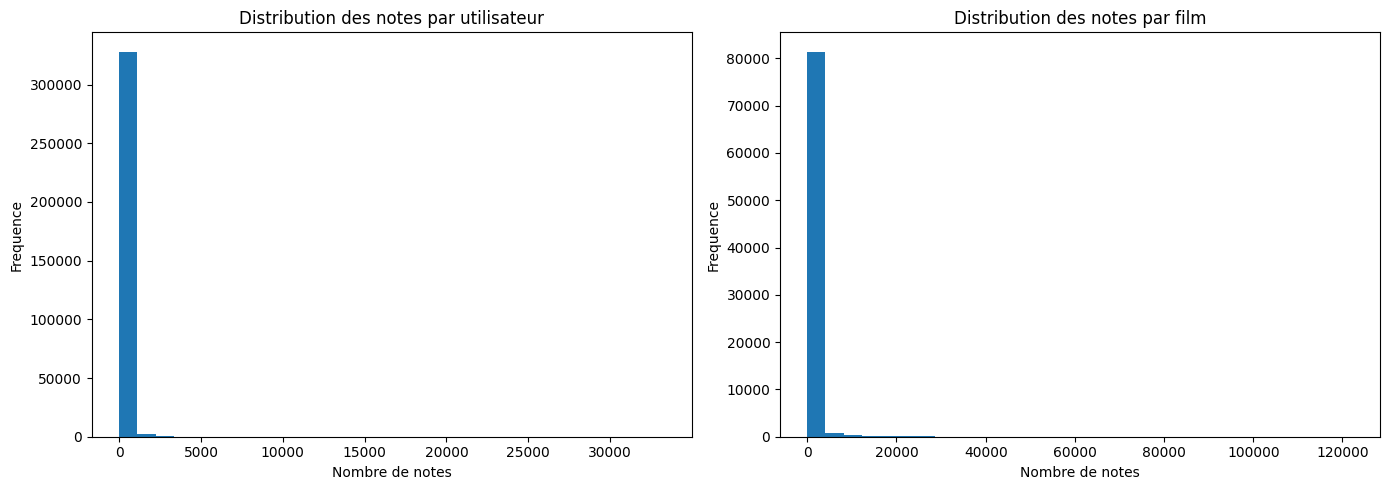

In [13]:
# Cellule autonome: on recree une session Spark et on recharge les donnees propres.
from pyspark.sql import SparkSession

spark = (
    SparkSession.builder.appName("MovieLensEDA")
    .config("spark.driver.memory", "8g") # Augmenter la memoire du driver
    .getOrCreate()
)
spark.sparkContext.setLogLevel("ERROR")

df_ratings = utils.load_ratings_dataframe(spark, path_ratings.as_posix())
df_movies = utils.load_movies_dataframe(spark, path_movies.as_posix())
df_ratings_clean, df_movies_clean = utils.clean_data(df_ratings, df_movies)

# Statistiques globales
n_users = df_ratings_clean.select("userId").distinct().count()
n_movies = df_ratings_clean.select("movieId").distinct().count()
n_interactions = df_ratings_clean.count()

density = n_interactions / (n_users * n_movies) if n_users and n_movies else 0.0

print("--- Baseline recommandations ---")
print(f"Utilisateurs uniques : {n_users}")
print(f"Films uniques : {n_movies}")
print(f"Interactions (ratings) : {n_interactions}")
print(f"Densite user-item : {density:.6f}")

# Distribution du nombre de notes par utilisateur
df_user_activity = (
    df_ratings_clean.groupBy("userId")
    .agg(F.count("*").alias("n_ratings_user"))
)

# Distribution du nombre de notes par film
df_item_activity = (
    df_ratings_clean.groupBy("movieId")
    .agg(F.count("*").alias("n_ratings_item"))
)

print("\n--- Activite utilisateurs (resume) ---")
df_user_activity.select("n_ratings_user").summary("count", "min", "25%", "50%", "75%", "max", "mean").show(truncate=False)

print("--- Activite films (resume) ---")
df_item_activity.select("n_ratings_item").summary("count", "min", "25%", "50%", "75%", "max", "mean").show(truncate=False)

# Taux d'utilisateurs/items rares
min_interactions = 5
rare_users = df_user_activity.filter(F.col("n_ratings_user") < min_interactions).count()
rare_items = df_item_activity.filter(F.col("n_ratings_item") < min_interactions).count()

rare_users_rate = rare_users / n_users if n_users else 0.0
rare_items_rate = rare_items / n_movies if n_movies else 0.0

print(f"Utilisateurs rares (< {min_interactions} notes): {rare_users} ({rare_users_rate:.2%})")
print(f"Films rares (< {min_interactions} notes): {rare_items} ({rare_items_rate:.2%})")

# Histogrammes (conversion pandas limitee pour visualisation)
import matplotlib.pyplot as plt

pdf_user = df_user_activity.select("n_ratings_user").toPandas()
pdf_item = df_item_activity.select("n_ratings_item").toPandas()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(pdf_user["n_ratings_user"], bins=30)
axes[0].set_title("Distribution des notes par utilisateur")
axes[0].set_xlabel("Nombre de notes")
axes[0].set_ylabel("Frequence")

axes[1].hist(pdf_item["n_ratings_item"], bins=30)
axes[1].set_title("Distribution des notes par film")
axes[1].set_xlabel("Nombre de notes")
axes[1].set_ylabel("Frequence")

plt.tight_layout()
plt.show()

<div style="color: #849dc9; background-color: #223f4d; padding: 10px; border-radius: 8px;" >

<h3>Lecture des résultats - Baseline recommandation</h3>

Les sorties affichées ci-dessus résument la structure du jeu de données nettoyé : nombre d'utilisateurs uniques, nombre de films uniques, volume total d'interactions et densité de la matrice user-item.

Les statistiques de résumé sur les interactions par utilisateur et par film permettent d'identifier la dispersion des notes et la présence d'une longue traîne.

Interprétation à faire :
- Une densité faible signifie une matrice creuse, ce qui est normal pour un problème de recommandation.
- Une forte proportion d'items peu notés indique un catalogue déséquilibré, avec des films difficiles à recommander de façon fiable.
- Les histogrammes servent à visualiser la distribution des interactions et à choisir des seuils minimaux avant modélisation.

</div>

<div style="color: #849dc9; background-color: #223f4d; padding: 10px; border-radius: 8px;" >
<h2>Split temporel anti-fuite</h2>

Le split temporel separe les interactions selon leur date (timestamp).<br>
Ancien pour entraînement, plus récent pour validation, plus récent encore pour test.

En production, on predit toujours le futur a partir du passe<br>
Le split temporel reproduit ce scenario reel, contrairement a un split aleatoire qui melange passe et futur<br>
Il limite la fuite de donnees (data leakage): le modele n'apprend pas sur des evenements qui se produisent apres ceux qu'il doit predire.
</div>

In [ ]:
# Split temporel global: 80% train, 10% validation, 10% test
quantiles = df_ratings_clean.approxQuantile("timestamp", [0.8, 0.9], 0.001)
t80, t90 = quantiles

df_train = df_ratings_clean.filter(F.col("timestamp") <= t80)
df_val = df_ratings_clean.filter((F.col("timestamp") > t80) & (F.col("timestamp") <= t90))
df_test = df_ratings_clean.filter(F.col("timestamp") > t90)

n_train = df_train.count()
n_val = df_val.count()
n_test = df_test.count()
n_total = n_train + n_val + n_test

print("--- Split temporel anti-fuite ---")
print(f"Seuil t80: {t80} | Seuil t90: {t90}")
print(f"Train: {n_train} ({n_train / n_total:.2%})")
print(f"Validation: {n_val} ({n_val / n_total:.2%})")
print(f"Test: {n_test} ({n_test / n_total:.2%})")

# Verification rapide des recouvrements de periodes
min_train_ts, max_train_ts = df_train.select(F.min("timestamp"), F.max("timestamp")).first()
min_val_ts, max_val_ts = df_val.select(F.min("timestamp"), F.max("timestamp")).first()
min_test_ts, max_test_ts = df_test.select(F.min("timestamp"), F.max("timestamp")).first()

print("\nPeriodes par split:")
print(f"Train:      [{min_train_ts}, {max_train_ts}]")
print(f"Validation: [{min_val_ts}, {max_val_ts}]")
print(f"Test:       [{min_test_ts}, {max_test_ts}]")

# Optionnel: persistance locale (utile si vous ne passez pas par Drive)
save_splits = False
if save_splits:
    data_size = DATA_SOURCE.replace("raw_", "")
    split_root = PROJECT_ROOT / "data" / "processed" / data_size / "splits_temporal"
    (df_train.write.mode("overwrite").parquet((split_root / "train").as_posix()))
    (df_val.write.mode("overwrite").parquet((split_root / "validation").as_posix()))
    (df_test.write.mode("overwrite").parquet((split_root / "test").as_posix()))
    print(f"Splits sauvegardes dans: {split_root}")

--- Split temporel anti-fuite ---
Seuil t80: 1531094329.0 | Seuil t90: 1598691989.0
Train: 27065730 (80.00%)
Validation: 3383216 (10.00%)
Test: 3383216 (10.00%)

Periodes par split:
Train:      [789652004, 1531094329]
Validation: [1531094337, 1598691989]
Test:       [1598692047, 1689843213]


<div style="color: #849dc9; background-color: #223f4d; padding: 10px; border-radius: 8px;" >

<h3>Lecture des résultats - Split temporel</h3>

La sortie affichée ci-dessus présente les seuils temporels utilisés pour séparer train, validation et test, ainsi que la proportion de lignes dans chaque sous-ensemble.

Ce qu'il faut vérifier :
- Les trois périodes doivent être non chevauchantes.
- Le train doit rester majoritaire pour permettre l'apprentissage.
- Validation et test doivent rester suffisants pour mesurer correctement la généralisation.

Cette étape confirme que le split respecte le scénario réel de prédiction du futur à partir du passé.

</div>

In [ ]:
import importlib
from pathlib import Path

import matplotlib.pyplot as plt
import src.utils as utils

utils = importlib.reload(utils)

from pyspark.sql import SparkSession, functions as F

# Configuration reproductibilite
RANDOM_SEED = 42
SAVE_ARTIFACTS = True

# Export principal vers Google Drive pour le notebook model.ipynb
SAVE_TO_DRIVE = True
DRIVE_OUTPUT_DIR = "/content/drive/MyDrive/sparkle_movie_processed_data"

# Cellule autonome: recree la session et recalcule les jeux propres/splits
spark = (
    SparkSession.builder.appName("MovieLensEDA")
    .master("local[*]")
    .config("spark.driver.memory", "8g")
    .getOrCreate()
)
spark.sparkContext.setLogLevel("ERROR")

df_ratings = utils.load_ratings_dataframe(spark, path_ratings.as_posix())
df_movies = utils.load_movies_dataframe(spark, path_movies.as_posix())
df_ratings_clean, df_movies_clean = utils.clean_data(df_ratings, df_movies)

quantiles = df_ratings_clean.approxQuantile("timestamp", [0.8, 0.9], 0.001)
t80, t90 = quantiles
df_train = df_ratings_clean.filter(F.col("timestamp") <= t80)
df_val = df_ratings_clean.filter((F.col("timestamp") > t80) & (F.col("timestamp") <= t90))
df_test = df_ratings_clean.filter(F.col("timestamp") > t90)

# Convention de sortie alignee avec model.ipynb: <base>/<small|big>/...
data_size = DATA_SOURCE.replace("raw_", "")
if SAVE_TO_DRIVE:
    output_root = Path(DRIVE_OUTPUT_DIR) / data_size
else:
    output_root = PROJECT_ROOT / "data" / "processed" / data_size

path_ratings_clean = output_root / "ratings_clean.parquet"
path_movies_clean = output_root / "movies_clean.parquet"
path_split_root = output_root / "splits_temporal"

if SAVE_ARTIFACTS:
    output_root.mkdir(parents=True, exist_ok=True)
    path_split_root.mkdir(parents=True, exist_ok=True)

    df_ratings_clean.write.mode("overwrite").parquet(path_ratings_clean.as_posix())
    df_movies_clean.write.mode("overwrite").parquet(path_movies_clean.as_posix())
    df_train.write.mode("overwrite").parquet((path_split_root / "train").as_posix())
    df_val.write.mode("overwrite").parquet((path_split_root / "validation").as_posix())
    df_test.write.mode("overwrite").parquet((path_split_root / "test").as_posix())

    print("--- Artefacts sauvegardes ---")
    print(f"ratings_clean: {path_ratings_clean}")
    print(f"movies_clean: {path_movies_clean}")
    print(f"splits: {path_split_root}")
    print(f"RANDOM_SEED configuree: {RANDOM_SEED}")
else:
    print("SAVE_ARTIFACTS=False: aucun fichier ecrit.")

--- Artefacts sauvegardes ---
ratings_clean: /content/drive/MyDrive/sparkle_movie_processed_data/ratings_clean.parquet
movies_clean: /content/drive/MyDrive/sparkle_movie_processed_data/movies_clean.parquet
splits: /content/drive/MyDrive/sparkle_movie_processed_data/splits_temporal
RANDOM_SEED configuree: 42


<div style="color: #849dc9; background-color: #223f4d; padding: 10px; border-radius: 8px;" >
<h2>Sauvegarde des artefacts</h2>
Cette section enregistre les données nettoyées et les splits temporels pour les réutiliser dans le notebook de modélisation.

Les chemins de sortie sont alignés avec l'export Drive du notebook EDA et le chargement attendu par le notebook ALS.

</div>

<div style="color: #849dc9; background-color: #223f4d; padding: 10px; border-radius: 8px;" >
<h2>Tendances generales</h2>
Calcule le top des films par note moyenne (avec seuil minimal de votes) et les genres les plus populaires.

In [16]:
# Top films et genres populaires
df_top_movies = utils.top_rated_movies(df_ratings_clean, df_movies_clean)
df_top_genres = utils.most_popular_genres(df_ratings_clean, df_movies_clean)

print("--- Top 10 films les mieux notes (min 50 votes) ---")
df_top_movies.show(10, truncate=False)

print("--- Top 10 genres les plus populaires ---")
df_top_genres.show(10, truncate=False)

--- Top 10 films les mieux notes (min 50 votes) ---
+-------+--------------------------------+------------------+---------+
|movieId|title                           |avg_rating        |n_ratings|
+-------+--------------------------------+------------------+---------+
|171011 |Planet Earth II (2016)          |4.451739343459089 |2041     |
|159817 |Planet Earth (2006)             |4.448092868988391 |3015     |
|170705 |Band of Brothers (2001)         |4.423985890652557 |2835     |
|318    |Shawshank Redemption, The (1994)|4.416792045528881 |122296   |
|171495 |Cosmos                          |4.3432            |625      |
|202439 |Parasite (2019)                 |4.3299459633841435|12399    |
|858    |Godfather, The (1972)           |4.32660258119567  |75004    |
|179135 |Blue Planet II (2017)           |4.312943962115233 |1267     |
|220528 |Twelve Angry Men (1954)         |4.305722891566265 |332      |
|198185 |Twin Peaks (1989)               |4.302561837455831 |1132     |
+-------+---

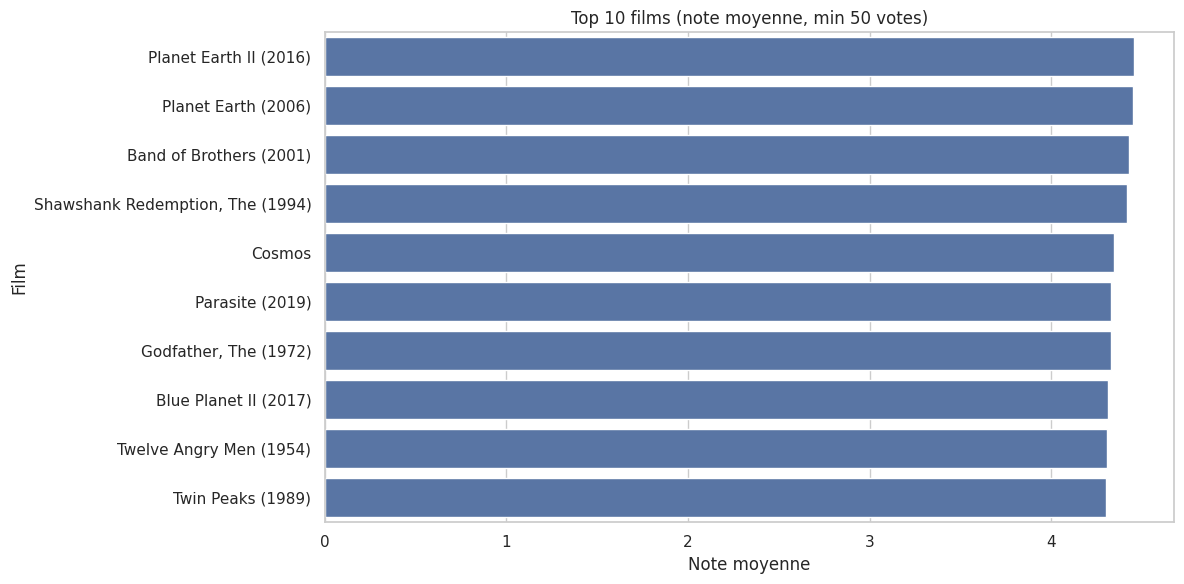

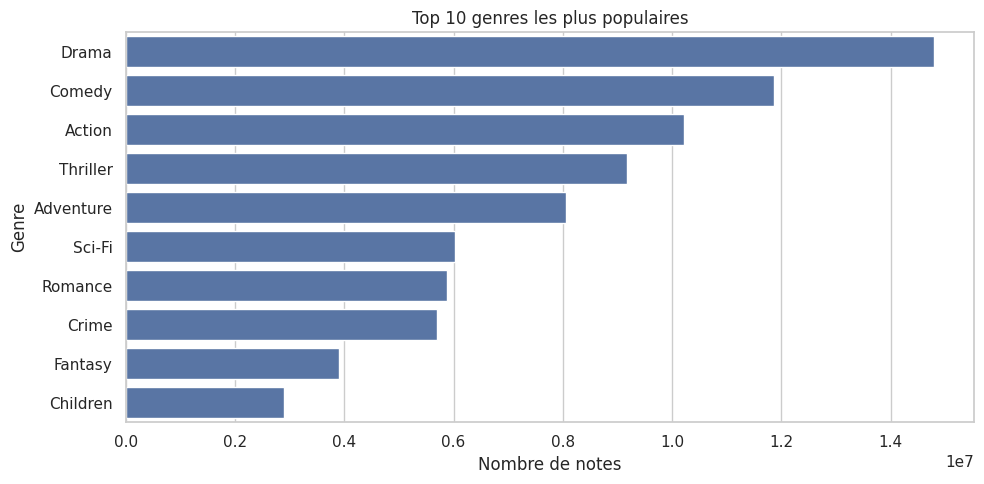

Plots enregistrés dans : /content/drive/MyDrive/sparkle_movie_processed_data/plots


In [17]:
import matplotlib.pyplot as plt

# Visualisations
utils.plot_results(df_top_movies, df_top_genres)

# S'assurer que output_root est défini par la cellule précédente (aac55fa4)
# et créer un répertoire pour les plots si nécessaire.
# On suppose que `output_root` est une variable globale définie précédemment.
if 'output_root' in globals():
    plots_dir = output_root / "plots"
    plots_dir.mkdir(parents=True, exist_ok=True)

    # Sauvegarder les plots générés par utils.plot_results
    # Assumant que utils.plot_results génère une seule figure matplotlib active
    # On peut personnaliser les noms de fichiers si plusieurs plots sont générés
    plt.savefig(plots_dir / "top_movies_genres_distribution.png")
    plt.close() # Fermer la figure pour libérer de la mémoire

    print(f"Plots enregistrés dans : {plots_dir}")
else:
    print("Attention: 'output_root' n'est pas défini. Les plots ne seront pas sauvegardés automatiquement.")

In [18]:
# Libération propre de la session Spark
spark.stop()
print("Session Spark arrêtée.")

Session Spark arrêtée.
